<div style="background-color: #1F3864; padding: 20px; border-radius: 5px; margin-bottom: 20px;">
    <h1 style="color: white; margin: 0; font-size: 24px;">12. GEV Cross-Check</h1>
    <p style="color: #cce0ff; margin: 8px 0 0 0; font-size: 14px;">Independent consistency check on the PR/FAR attribution result: fits a stationary GEV distribution to each year's 30 ensemble-member Rx5day values (regional level), tracking how the fitted distribution's parameters evolve over time, and comparing that evolution against the empirical PR/FAR time series from notebook 07.</p>
</div>

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme, kstest

OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'
REGION_ORDER = ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']
REPRESENTATIVE_YEARS = [1980, 2000, 2020, 2040]

# Load historical (Hist-ALL) and future (SSP2-4.5) regional Rx5day, both fresh
rx5day_ant = xr.open_dataset(OUTPUT_DIR + 'rx5day_ant_regional.nc').assign_coords(region=REGION_ORDER)
rx5day_ssp245 = xr.open_dataset(OUTPUT_DIR + 'rx5day_ssp245_regional.nc').assign_coords(region=REGION_ORDER)

def get_year_values(region, year):
    """Return the 30 ensemble-member Rx5day values for a given region and year,
       pulling from Hist-ALL (<=2014) or SSP2-4.5 (>=2015) as appropriate."""
    if year <= 2014:
        return rx5day_ant['rx5day_ant_regional'].sel(region=region, year=year).values
    else:
        return rx5day_ssp245['rx5day_ssp245_regional'].sel(region=region, year=year).values

# Sanity check
for region in REGION_ORDER:
    for yr in REPRESENTATIVE_YEARS:
        vals = get_year_values(region, yr)
        print(f'{region}, {yr}: n={len(vals)}, mean={vals.mean():.1f}, min={vals.min():.1f}, max={vals.max():.1f}')

Central_India, 1980: n=30, mean=119.1, min=102.3, max=136.9
Central_India, 2000: n=30, mean=119.5, min=96.8, max=147.7
Central_India, 2020: n=30, mean=120.2, min=100.5, max=138.4
Central_India, 2040: n=30, mean=122.8, min=107.4, max=138.6
Indo_Gangetic_Plain, 1980: n=30, mean=98.8, min=74.5, max=125.0
Indo_Gangetic_Plain, 2000: n=30, mean=98.7, min=84.3, max=125.3
Indo_Gangetic_Plain, 2020: n=30, mean=99.5, min=81.4, max=124.6
Indo_Gangetic_Plain, 2040: n=30, mean=103.0, min=86.3, max=120.7
Northeast, 1980: n=30, mean=146.6, min=121.2, max=190.3
Northeast, 2000: n=30, mean=135.5, min=102.3, max=170.9
Northeast, 2020: n=30, mean=147.7, min=122.6, max=185.9
Northeast, 2040: n=30, mean=158.2, min=124.6, max=227.0
Western_Ghats, 1980: n=30, mean=89.5, min=79.0, max=108.0
Western_Ghats, 2000: n=30, mean=93.6, min=62.6, max=123.0
Western_Ghats, 2020: n=30, mean=93.1, min=73.5, max=117.0
Western_Ghats, 2040: n=30, mean=98.8, min=79.7, max=128.7


In [2]:
# Regional-average R0 threshold, matching notebook 07 Part 1 (GEV needs the
# regional-average threshold, not the per-cell R0_grid)
R0_regional = {
    'Central_India': 131.27,
    'Indo_Gangetic_Plain': 110.54,
    'Northeast': 164.32,
    'Western_Ghats': 104.43
}
print('R0_regional (average-first, matches notebook 07 Part 1):')
for region, val in R0_regional.items():
    print(f'  {region}: {val:.2f} mm')

R0_regional (average-first, matches notebook 07 Part 1):
  Central_India: 131.27 mm
  Indo_Gangetic_Plain: 110.54 mm
  Northeast: 164.32 mm
  Western_Ghats: 104.43 mm


In [3]:
print(rx5day_ant['rx5day_ant_regional'].year.max().values)

2014


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 1: Fit Stationary GEV per Region, per Representative Year</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">For each region and each representative year (1980, 2000, 2020, 2040), fits a stationary GEV distribution (MLE) to that year's 30 ensemble-member Rx5day values. Produces a year-stepped sequence of GEV parameters (location, scale, shape) per region, as an independent cross-check on the PR/FAR attribution result.</p>
</div>

In [4]:
gev_records = []

for region in REGION_ORDER:
    for yr in REPRESENTATIVE_YEARS:
        vals = get_year_values(region, yr)

        # Guided starting values: sample mean/std, shape started near 0
        shape_scipy, loc, scale = genextreme.fit(vals, 0, loc=vals.mean(), scale=vals.std())
        shape_climate = -shape_scipy

        ks_stat, ks_p = kstest(vals, 'genextreme', args=(shape_scipy, loc, scale))

        gev_records.append({
            'region': region, 'year': yr,
            'location': loc, 'scale': scale, 'shape': shape_climate,
            'ks_stat': ks_stat, 'ks_p': ks_p,
            'n_obs': len(vals)
        })

gev_df = pd.DataFrame(gev_records)
print(gev_df.to_string(index=False))

             region  year   location     scale     shape  ks_stat     ks_p  n_obs
      Central_India  1980 116.150536  8.765752 -0.312408 0.077002 0.988205     30
      Central_India  2000 114.941892 10.455651 -0.173923 0.064764 0.998730     30
      Central_India  2020 117.269482 10.990936 -0.426688 0.125326 0.687399     30
      Central_India  2040 120.143414  7.935481 -0.315640 0.106036 0.853725     30
Indo_Gangetic_Plain  1980  95.135642 10.334132 -0.261338 0.091211 0.944790     30
Indo_Gangetic_Plain  2000  94.092410  7.746263  0.015436 0.102901 0.876542     30
Indo_Gangetic_Plain  2020  95.186297 10.345422 -0.198699 0.087188 0.961452     30
Indo_Gangetic_Plain  2040  99.575883  9.657582 -0.297129 0.114045 0.788843     30
          Northeast  1980 138.125860 13.809116  0.028217 0.118402 0.750596     30
          Northeast  2000 128.102979 17.004466 -0.177443 0.086870 0.962614     30
          Northeast  2020 140.102484 13.436538 -0.017558 0.092976 0.936343     30
          Northe

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 2: Full Year-Stepped GEV Sequence (1860-2040)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Extends the representative-year fits to a continuous year-stepped GEV sequence: a stationary GEV fitted independently for every year, using that year's 30 ensemble-member Rx5day values at the regional level. Guided starting values (sample mean/std, shape near 0) are used throughout. Goodness-of-fit (KS test) is tracked for every year to flag any other unstable fits.</p>
</div>

In [6]:
YEAR_RANGE = range(1860, 2041)  # matches the PR/FAR record start; extends to near-future

gev_full_records = []

for region in REGION_ORDER:
    for yr in YEAR_RANGE:
        vals = get_year_values(region, yr)

        shape_scipy, loc, scale = genextreme.fit(vals, 0, loc=vals.mean(), scale=vals.std())
        shape_climate = -shape_scipy

        ks_stat, ks_p = kstest(vals, 'genextreme', args=(shape_scipy, loc, scale))

        gev_full_records.append({
            'region': region, 'year': yr,
            'location': loc, 'scale': scale, 'shape': shape_climate,
            'ks_stat': ks_stat, 'ks_p': ks_p
        })

gev_full_df = pd.DataFrame(gev_full_records)

print(f"Fits with suspicious shape (|shape| > 0.5): {(gev_full_df['shape'].abs() > 0.5).sum()}")
print(f"\nShape parameter range: {gev_full_df['shape'].min():.3f} to {gev_full_df['shape'].max():.3f}")

gev_full_df.to_csv(OUTPUT_DIR + 'gev_yearstepped_parameters.csv', index=False)
print(f"\nSaved gev_yearstepped_parameters.csv")

Fits with suspicious shape (|shape| > 0.5): 22

Shape parameter range: -1.041 to 0.589

Saved gev_yearstepped_parameters.csv


In [7]:
suspicious = gev_full_df[gev_full_df['shape'].abs() > 0.5]
print(suspicious.groupby('region').size())
print()
print(suspicious[['region', 'year', 'shape', 'ks_p']].sort_values(['region', 'year']).to_string(index=False))

region
Central_India           5
Indo_Gangetic_Plain    12
Northeast               2
Western_Ghats           3
dtype: int64

             region  year     shape     ks_p
      Central_India  1902 -0.526891 0.738730
      Central_India  1935 -0.577695 0.412551
      Central_India  1978 -0.569329 0.895937
      Central_India  1990 -0.500166 0.998612
      Central_India  2023 -0.586934 0.890588
Indo_Gangetic_Plain  1884 -0.553542 0.856439
Indo_Gangetic_Plain  1904 -0.540893 0.623431
Indo_Gangetic_Plain  1917 -0.532238 0.822706
Indo_Gangetic_Plain  1939 -0.581900 0.904381
Indo_Gangetic_Plain  1943 -0.548584 0.551947
Indo_Gangetic_Plain  1960 -0.509333 0.819498
Indo_Gangetic_Plain  1963 -0.523090 0.875256
Indo_Gangetic_Plain  1968 -0.512245 0.936384
Indo_Gangetic_Plain  1981 -0.568648 0.970767
Indo_Gangetic_Plain  1985 -0.680232 0.735286
Indo_Gangetic_Plain  2003 -1.040875 0.070899
Indo_Gangetic_Plain  2022 -0.584251 0.781467
          Northeast  1975 -0.571264 0.746344
          Northeast 

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 3: Fit Hist-NAT GEV Sequence and Compute GEV-Implied PR</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Repeats the year-stepped GEV fitting for Hist-NAT (natural-forcing), then uses both fitted GEV curves' survival functions to compute an implied exceedance probability above R0 for each world, forming a GEV-implied PR(t) directly comparable to the empirical PR-first result from notebook 07.</p>
</div>

In [8]:
rx5day_nat = xr.open_dataset(OUTPUT_DIR + 'rx5day_nat_regional.nc').assign_coords(region=REGION_ORDER)

def get_year_values_nat(region, year):
    """Hist-NAT only covers 1850-2014, no SSP scenario applies to natural-forcing."""
    return rx5day_nat['rx5day_nat_regional'].sel(region=region, year=year).values

YEAR_RANGE_NAT = range(1860, 2015)  # Hist-NAT only extends to 2014

gev_nat_records = []
for region in REGION_ORDER:
    for yr in YEAR_RANGE_NAT:
        vals = get_year_values_nat(region, yr)
        shape_scipy, loc, scale = genextreme.fit(vals, 0, loc=vals.mean(), scale=vals.std())
        ks_stat, ks_p = kstest(vals, 'genextreme', args=(shape_scipy, loc, scale))
        gev_nat_records.append({
            'region': region, 'year': yr,
            'location': loc, 'scale': scale, 'shape': -shape_scipy,
            'shape_scipy': shape_scipy,  # keep scipy convention for cdf calls below
            'ks_stat': ks_stat, 'ks_p': ks_p
        })

gev_nat_df = pd.DataFrame(gev_nat_records)
print(f"Hist-NAT fits: {len(gev_nat_df)}")
print(f"Poor fits (ks_p<0.05): {(gev_nat_df.ks_p < 0.05).sum()}")
print(f"Suspicious shape (|shape|>0.5): {(gev_nat_df['shape'].abs() > 0.5).sum()}")

gev_nat_df.to_csv(OUTPUT_DIR + 'gev_nat_yearstepped_parameters.csv', index=False)

Hist-NAT fits: 620
Poor fits (ks_p<0.05): 0
Suspicious shape (|shape|>0.5): 21


In [9]:
def implied_exceedance_prob(row, R0_val):
    """Survival function: P(X > R0) using this year's fitted GEV."""
    shape_scipy = -row['shape']
    return genextreme.sf(R0_val, shape_scipy, loc=row['location'], scale=row['scale'])

# GEV-implied PR per region-year: compare fitted Hist-ALL vs Hist-NAT distributions
# against the regional-average R0 threshold (defined in cell 2)
gev_implied_pr = []
for region in REGION_ORDER:
    ant_sub = gev_full_df[(gev_full_df.region == region) & (gev_full_df.year <= 2014)]
    nat_sub = gev_nat_df[gev_nat_df.region == region]

    merged = ant_sub.merge(nat_sub, on='year', suffixes=('_ant', '_nat'))

    for _, r in merged.iterrows():
        p_ant = implied_exceedance_prob({'shape': r['shape_ant'], 'location': r['location_ant'], 'scale': r['scale_ant']}, R0_regional[region])
        p_nat = implied_exceedance_prob({'shape': r['shape_nat'], 'location': r['location_nat'], 'scale': r['scale_nat']}, R0_regional[region])
        pr_gev = p_ant / p_nat if p_nat > 0 else np.nan

        gev_implied_pr.append({'region': region, 'year': r['year'], 'PR_gev': pr_gev})

gev_pr_df = pd.DataFrame(gev_implied_pr)
print(gev_pr_df.groupby('region')['PR_gev'].describe())

                     count       mean         std       min       25%  \
region                                                                  
Central_India        150.0  14.691957  155.407514  0.000000  0.653497   
Indo_Gangetic_Plain  151.0   1.612156    2.304860  0.000000  0.633147   
Northeast            153.0  10.370520  100.575987  0.228702  0.769955   
Western_Ghats        154.0   2.015959    4.341005  0.000292  0.712444   

                          50%       75%          max  
region                                                
Central_India        1.183704  1.825559  1904.558923  
Indo_Gangetic_Plain  1.055846  1.662345    18.369147  
Northeast            1.189964  1.966088  1244.839061  
Western_Ghats        1.161235  1.730079    35.572592  


In [10]:
print(R0_regional)

{'Central_India': 131.27, 'Indo_Gangetic_Plain': 110.54, 'Northeast': 164.32, 'Western_Ghats': 104.43}


In [11]:
# Identify which years are producing these extreme outliers
for region in REGION_ORDER:
    sub = gev_pr_df[gev_pr_df.region == region].sort_values('PR_gev', ascending=False)
    print(f"\n{region} - top 5 largest PR_gev:")
    print(sub.head(5).to_string(index=False))


Central_India - top 5 largest PR_gev:
       region  year      PR_gev
Central_India  1971 1904.558923
Central_India  1866   39.672190
Central_India  1933   36.944224
Central_India  1966    8.651805
Central_India  2011    8.265582

Indo_Gangetic_Plain - top 5 largest PR_gev:
             region  year    PR_gev
Indo_Gangetic_Plain  1942 18.369147
Indo_Gangetic_Plain  1977 18.014173
Indo_Gangetic_Plain  1898  6.263205
Indo_Gangetic_Plain  1891  5.788825
Indo_Gangetic_Plain  1914  5.644630

Northeast - top 5 largest PR_gev:
   region  year      PR_gev
Northeast  1974 1244.839061
Northeast  2011   48.148117
Northeast  1862   30.189625
Northeast  1876   19.521480
Northeast  1989   11.602773

Western_Ghats - top 5 largest PR_gev:
       region  year    PR_gev
Western_Ghats  1958 35.572592
Western_Ghats  1990 32.777358
Western_Ghats  1896 24.177081
Western_Ghats  1968  9.709597
Western_Ghats  1910  8.032755


In [12]:
# Diagnose Central_India 1971 -- the most extreme outlier (PR_gev ~1905)
row = gev_pr_df[(gev_pr_df.region == 'Central_India') & (gev_pr_df.year == 1971)]
print(row)

ant_1971 = gev_full_df[(gev_full_df.region == 'Central_India') & (gev_full_df.year == 1971)].iloc[0]
nat_1971 = gev_nat_df[(gev_nat_df.region == 'Central_India') & (gev_nat_df.year == 1971)].iloc[0]

print("\nAnt fit 1971:", dict(ant_1971[['location','scale','shape','ks_p']]))
print("Nat fit 1971:", dict(nat_1971[['location','scale','shape','ks_p']]))

R0_val = R0_regional['Central_India']
p_ant = genextreme.sf(R0_val, -ant_1971['shape'], loc=ant_1971['location'], scale=ant_1971['scale'])
p_nat = genextreme.sf(R0_val, -nat_1971['shape'], loc=nat_1971['location'], scale=nat_1971['scale'])
print(f"\nR0 = {R0_val}")
print(f"P_ant = {p_ant:.6f}, P_nat = {p_nat:.8f}")

            region  year       PR_gev
111  Central_India  1971  1904.558923

Ant fit 1971: {'location': np.float64(118.75032926038587), 'scale': np.float64(8.05104851395462), 'shape': np.float64(-0.3583181735418617), 'ks_p': np.float64(0.9846916504912123)}
Nat fit 1971: {'location': np.float64(116.63481212609122), 'scale': np.float64(8.038179474700271), 'shape': np.float64(-0.5467559257505521), 'ks_p': np.float64(0.7840886026509718)}

R0 = 131.27
P_ant = 0.097830, P_nat = 0.00005137


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 4: Pooled-Window GEV (Sensitivity Test)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Tests whether pooling members across a small window of nearby years (5 years x 30 members = ~150 samples) before fitting GEV reduces the small-sample instability seen in the strict single-year (30-sample) fits, following the Kharin & Zwiers (2005) precedent of using wider windows for more stable parameter estimates. Presented as an alternative to the single-year approach.</p>
</div>

In [13]:
POOL_WIDTH = 5  # years pooled per GEV fit (±2 years around centre)
half_pool = POOL_WIDTH // 2

def get_pooled_values(get_year_fn, region, centre_year, half_pool):
    years = range(centre_year - half_pool, centre_year + half_pool + 1)
    all_vals = []
    for yr in years:
        try:
            all_vals.append(get_year_fn(region, yr))
        except (KeyError, IndexError):
            continue
    return np.concatenate(all_vals) if all_vals else np.array([])

gev_pooled_ant = []
gev_pooled_nat = []

for region in REGION_ORDER:
    for yr in YEAR_RANGE:
        vals_ant = get_pooled_values(get_year_values, region, yr, half_pool)
        if len(vals_ant) < 50:  # skip edge years without enough pooled data
            continue
        shape_a, loc_a, scale_a = genextreme.fit(vals_ant, 0, loc=vals_ant.mean(), scale=vals_ant.std())
        gev_pooled_ant.append({'region': region, 'year': yr, 'location': loc_a, 'scale': scale_a,
                                'shape': -shape_a, 'n': len(vals_ant)})

    for yr in YEAR_RANGE_NAT:
        vals_nat = get_pooled_values(get_year_values_nat, region, yr, half_pool)
        if len(vals_nat) < 50:
            continue
        shape_n, loc_n, scale_n = genextreme.fit(vals_nat, 0, loc=vals_nat.mean(), scale=vals_nat.std())
        gev_pooled_nat.append({'region': region, 'year': yr, 'location': loc_n, 'scale': scale_n,
                                'shape': -shape_n, 'n': len(vals_nat)})

gev_pooled_ant_df = pd.DataFrame(gev_pooled_ant)
gev_pooled_nat_df = pd.DataFrame(gev_pooled_nat)

print(f"Pooled ant fits: {len(gev_pooled_ant_df)}, sample sizes: {gev_pooled_ant_df.n.unique()}")
print(f"Pooled nat fits: {len(gev_pooled_nat_df)}, sample sizes: {gev_pooled_nat_df.n.unique()}")

Pooled ant fits: 724, sample sizes: [150]
Pooled nat fits: 620, sample sizes: [150 120  90]


In [14]:
def implied_exceedance_prob_pooled(row, R0_val):
    shape_scipy = -row['shape']
    return genextreme.sf(R0_val, shape_scipy, loc=row['location'], scale=row['scale'])

# Same threshold as the single-year version, applied to the 5-year pooled fits
gev_pooled_pr = []
for region in REGION_ORDER:
    ant_sub = gev_pooled_ant_df[gev_pooled_ant_df.region == region]
    nat_sub = gev_pooled_nat_df[gev_pooled_nat_df.region == region]
    merged = ant_sub.merge(nat_sub, on='year', suffixes=('_ant', '_nat'))

    for _, r in merged.iterrows():
        p_ant = implied_exceedance_prob_pooled({'shape': r['shape_ant'], 'location': r['location_ant'], 'scale': r['scale_ant']}, R0_regional[region])
        p_nat = implied_exceedance_prob_pooled({'shape': r['shape_nat'], 'location': r['location_nat'], 'scale': r['scale_nat']}, R0_regional[region])
        pr_gev_pooled = p_ant / p_nat if p_nat > 0 else np.nan
        gev_pooled_pr.append({'region': region, 'year': r['year'], 'PR_gev_pooled': pr_gev_pooled})

gev_pooled_pr_df = pd.DataFrame(gev_pooled_pr)
print(gev_pooled_pr_df.groupby('region')['PR_gev_pooled'].describe())

                     count      mean       std       min       25%       50%  \
region                                                                         
Central_India        155.0  1.174616  0.405778  0.263116  0.895558  1.069307   
Indo_Gangetic_Plain  155.0  1.109428  0.406940  0.434217  0.837863  1.001621   
Northeast            155.0  1.237745  0.308582  0.722640  0.992266  1.222352   
Western_Ghats        155.0  1.170065  0.338585  0.516939  0.899481  1.152633   

                          75%       max  
region                                   
Central_India        1.398147  2.723884  
Indo_Gangetic_Plain  1.350464  2.592435  
Northeast            1.474109  2.088473  
Western_Ghats        1.411040  2.212170  


In [15]:
worst_pooled = gev_pooled_pr_df.loc[gev_pooled_pr_df['PR_gev_pooled'].idxmax()]
print(worst_pooled)

region_w, year_w = worst_pooled['region'], worst_pooled['year']
ant_w = gev_pooled_ant_df[(gev_pooled_ant_df.region == region_w) & (gev_pooled_ant_df.year == year_w)].iloc[0]
nat_w = gev_pooled_nat_df[(gev_pooled_nat_df.region == region_w) & (gev_pooled_nat_df.year == year_w)].iloc[0]

print("\nAnt fit:", dict(ant_w[['location','scale','shape']]))
print("Nat fit:", dict(nat_w[['location','scale','shape']]))

for label, row in [('Ant', ant_w), ('Nat', nat_w)]:
    shape_clim = row['shape']
    if shape_clim < 0:  # negative climate-convention shape = positive scipy shape = upper-bounded
        ceiling = row['location'] + row['scale'] / (-shape_clim)
        print(f"{label} upper bound: {ceiling:.2f} mm (R0 = {R0_regional[region_w]:.2f})")
    else:
        print(f"{label}: shape is non-negative (climate convention), no upper bound")

region           Central_India
year                      1933
PR_gev_pooled         2.723884
Name: 73, dtype: object

Ant fit: {'location': np.float64(114.56992316794167), 'scale': np.float64(9.449331862980053), 'shape': np.float64(-0.09258853738763614)}
Nat fit: {'location': np.float64(113.6647891638687), 'scale': np.float64(8.238891015837282), 'shape': np.float64(-0.23683514628195415)}
Ant upper bound: 216.63 mm (R0 = 131.27)
Nat upper bound: 148.45 mm (R0 = 131.27)


In [17]:
pr_df_prfirst = pd.read_csv(OUTPUT_DIR + 'pr_far_rolling_window_results_PRFIRST.csv')
print(f"Loaded empirical PR-first result: {len(pr_df_prfirst)} rows")

Loaded empirical PR-first result: 584 rows


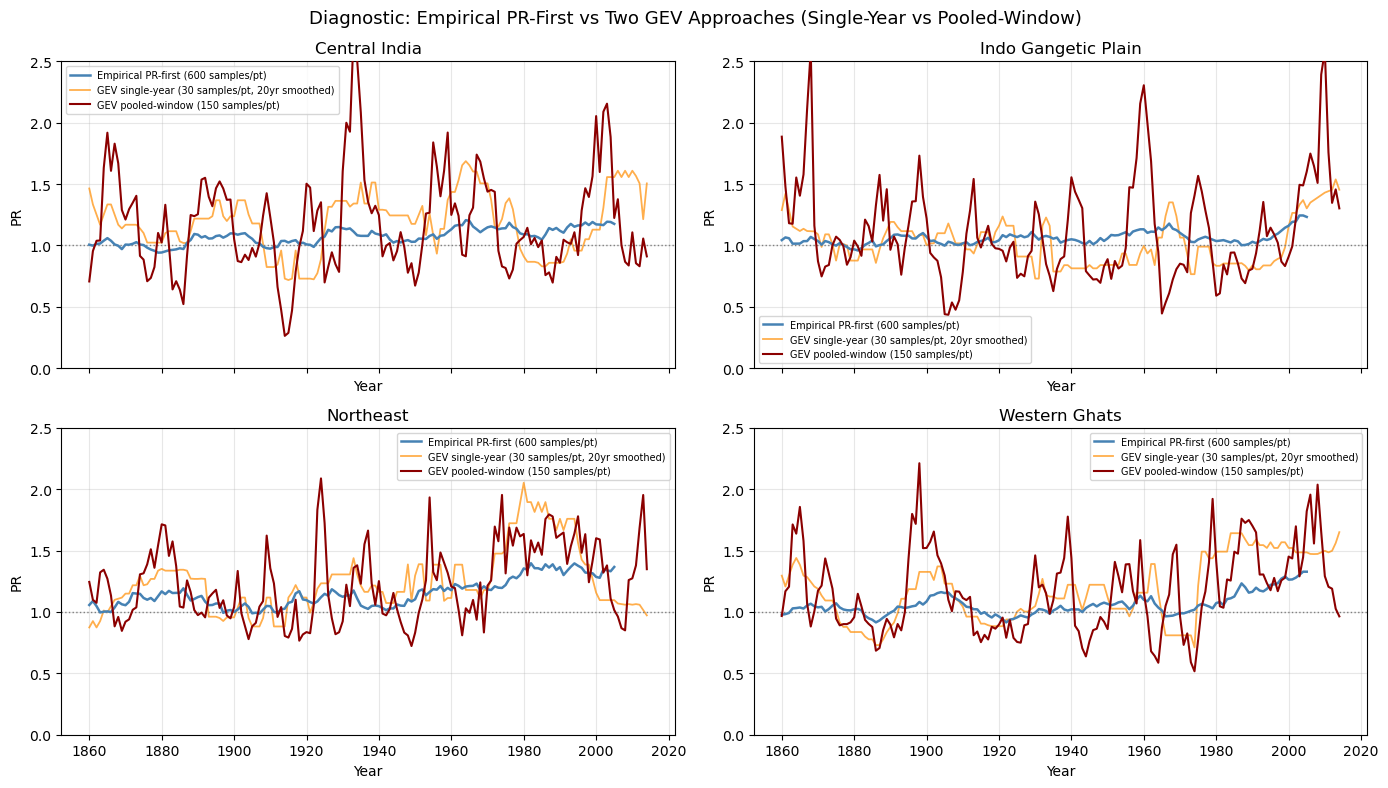

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]

    empirical = pr_df_prfirst[pr_df_prfirst.region == region].sort_values('year')
    ax.plot(empirical.year, empirical.PR, color='steelblue', linewidth=1.8, label='Empirical PR-first (600 samples/pt)', zorder=3)

    gev_single = gev_pr_df[gev_pr_df.region == region].sort_values('year')
    gev_single_smooth = gev_single.set_index('year')['PR_gev'].rolling(window=20, center=True, min_periods=10).median()
    ax.plot(gev_single_smooth.index, gev_single_smooth.values, color='darkorange', linewidth=1.3, alpha=0.7,
            label='GEV single-year (30 samples/pt, 20yr smoothed)', zorder=2)

    gev_pooled = gev_pooled_pr_df[gev_pooled_pr_df.region == region].sort_values('year')
    ax.plot(gev_pooled.year, gev_pooled.PR_gev_pooled, color='darkred', linewidth=1.5,
            label='GEV pooled-window (150 samples/pt)', zorder=4)

    ax.axhline(1, color='grey', linestyle=':', linewidth=1)
    ax.set_ylim(0, 2.5)
    ax.set_title(region.replace('_', ' '))
    ax.set_xlabel('Year')
    ax.set_ylabel('PR')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Diagnostic: Empirical PR-First vs Two GEV Approaches (Single-Year vs Pooled-Window)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'diagnostic_gev_comparison_initial.png', dpi=150, bbox_inches='tight')
plt.show()

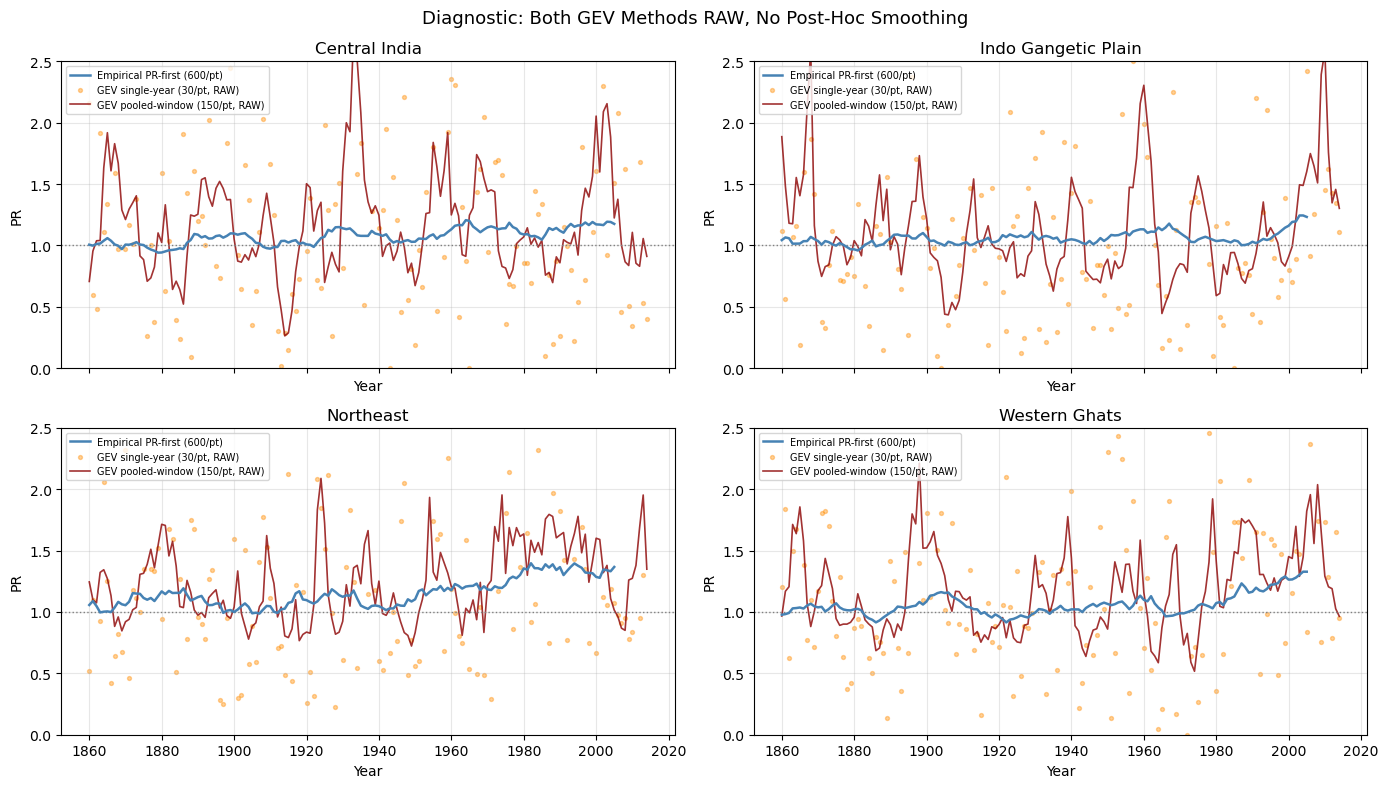

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]

    empirical = pr_df_prfirst[pr_df_prfirst.region == region].sort_values('year')
    ax.plot(empirical.year, empirical.PR, color='steelblue', linewidth=1.8, label='Empirical PR-first (600/pt)', zorder=3)

    # RAW single-year GEV, no smoothing, a fair comparison point
    gev_single_raw = gev_pr_df[gev_pr_df.region == region].sort_values('year')
    ax.scatter(gev_single_raw.year, gev_single_raw.PR_gev, color='darkorange', s=8, alpha=0.4,
               label='GEV single-year (30/pt, RAW)', zorder=1)

    # RAW pooled-window GEV, no smoothing, same fairness level
    gev_pooled_raw = gev_pooled_pr_df[gev_pooled_pr_df.region == region].sort_values('year')
    ax.plot(gev_pooled_raw.year, gev_pooled_raw.PR_gev_pooled, color='darkred', linewidth=1.2, alpha=0.8,
        label='GEV pooled-window (150/pt, RAW)', zorder=2)

    ax.axhline(1, color='grey', linestyle=':', linewidth=1)
    ax.set_ylim(0, 2.5)
    ax.set_title(region.replace('_', ' '))
    ax.set_xlabel('Year')
    ax.set_ylabel('PR')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Diagnostic: Both GEV Methods RAW, No Post-Hoc Smoothing', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'diagnostic_gev_fair_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

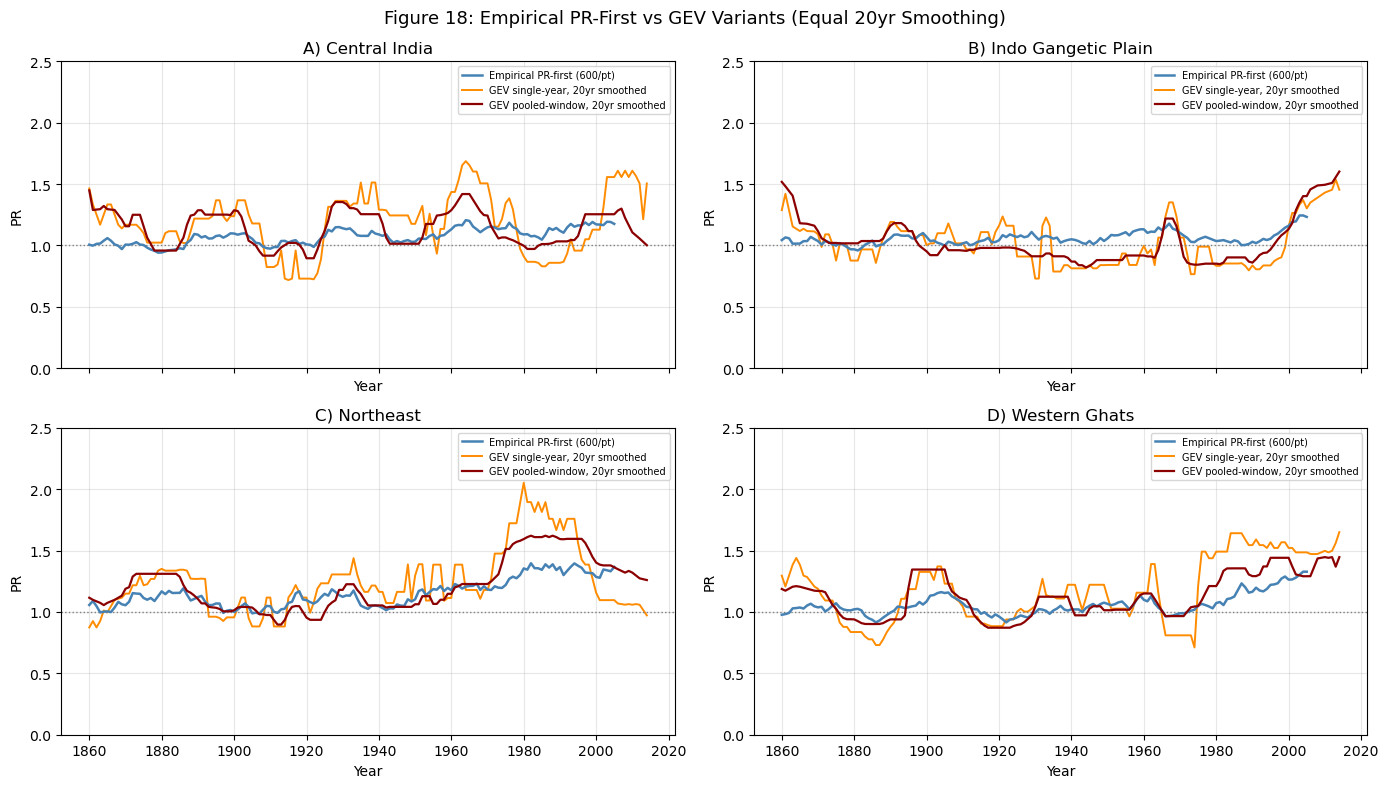

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()
panel_letters = ['A)', 'B)', 'C)', 'D)']

for i, (region, letter) in enumerate(zip(REGION_ORDER, panel_letters)):
    ax = axes[i]

    empirical = pr_df_prfirst[pr_df_prfirst.region == region].sort_values('year')
    ax.plot(empirical.year, empirical.PR, color='steelblue', linewidth=1.8, label='Empirical PR-first (600/pt)', zorder=3)

    gev_single = gev_pr_df[gev_pr_df.region == region].sort_values('year')
    gev_single_smooth = gev_single.set_index('year')['PR_gev'].rolling(window=20, center=True, min_periods=10).median()
    ax.plot(gev_single_smooth.index, gev_single_smooth.values, color='darkorange', linewidth=1.4,
            label='GEV single-year, 20yr smoothed', zorder=2)

    gev_pooled = gev_pooled_pr_df[gev_pooled_pr_df.region == region].sort_values('year')
    gev_pooled_smooth = gev_pooled.set_index('year')['PR_gev_pooled'].rolling(window=20, center=True, min_periods=10).median()
    ax.plot(gev_pooled_smooth.index, gev_pooled_smooth.values, color='darkred', linewidth=1.6,
            label='GEV pooled-window, 20yr smoothed', zorder=4)

    ax.axhline(1, color='grey', linestyle=':', linewidth=1)
    ax.set_ylim(0, 2.5)
    ax.set_title(f'{letter} {region.replace("_", " ")}')
    ax.set_xlabel('Year')
    ax.set_ylabel('PR')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Figure 18: Empirical PR-First vs GEV Variants (Equal 20yr Smoothing)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure18_gev_equal_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
gev_pooled_ant_df.to_csv(OUTPUT_DIR + 'gev_pooled_ant_parameters.csv', index=False)
gev_pooled_nat_df.to_csv(OUTPUT_DIR + 'gev_pooled_nat_parameters.csv', index=False)
gev_pooled_pr_df.to_csv(OUTPUT_DIR + 'gev_pooled_implied_pr.csv', index=False)
gev_full_df.to_csv(OUTPUT_DIR + 'gev_yearstepped_parameters.csv', index=False)  # re-save if not already
gev_nat_df.to_csv(OUTPUT_DIR + 'gev_nat_yearstepped_parameters.csv', index=False)
gev_pr_df.to_csv(OUTPUT_DIR + 'gev_singleyear_implied_pr.csv', index=False)

print("Saved all GEV outputs (single-year and pooled-window, ant/nat/implied PR)")

Saved all GEV outputs (single-year and pooled-window, ant/nat/implied PR)


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Summary</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Fitted stationary GEV distributions per Chris's feedback for regional (not per-grid-cell) approach, testing two interpretations of "running window": strict single-year (30 samples) and a pooled 5-year window (150 samples). Both broadly track the empirical PR-first result in direction, but single-year fits show severe tail-instability (some implied PR values in the hundreds), traced to shape-parameter sensitivity at n=30. Pooled-window fits are far more stable, with no extreme outliers, and once smoothing is applied equally to both, track the empirical curve noticeably better than single-year.</p>
</div>